# Price vs Weather (with Demand control) — NEM Analysis Notebook

Goal: Estimate and interpret
`RRP ~ Temp + Temp^2 + Humidity + Wind + Demand + Season + Time-of-day + Weekend`
for a chosen NEM region (e.g., VIC1).

This notebook:
- Loads RRP (from a combined 30-min file or builds from DATA*.csv),
- Loads demand + weather,
- Aligns timestamps on a 30-min grid (DST-safe),
- Produces descriptive plots (intraday profiles, binned medians),
- Fits OLS and Huber regressions and reports R^2, RMSE, MAE,
- Provides effect plots and diagnostics,
- (Optional) Simple spike classification via Logistic and kNN.


In [28]:
# === 0) Configuration (edit paths/region here) ===
PROJ_ROOT = r"ADS1002-project-main"

# Price sources
RAW_PRICE_DIR      = rf"{PROJ_ROOT}\Data\raw\Demand"   # <- your DATA*.csv live here
COMBINED_RRP_CSV   = rf"{PROJ_ROOT}\Data\clean\Price\RRP_30min_combined.csv"

# Region / timezone (SA example)
STATE    = "SA"
REGIONID = "SA1"
LOCAL_TZ = "Australia/Adelaide"

# Demand + Weather (the file you just built)
DEMAND_WEATHER_CSV = rf"{PROJ_ROOT}\Data\clean\WeatherDemand\std_{STATE}.csv"

# Plot/cleaning knobs
WINSOR_P = 0.01
N_BINS = 12
ROLLING_WINDOW = 1
Y_MAX_PRICE = None

# Outputs
OUTDIR = rf"{PROJ_ROOT}\Data\analysis\PriceWeatherDemand"

import os, pathlib
pathlib.Path(OUTDIR).mkdir(parents=True, exist_ok=True)

# Print AFTER all assignments so it's consistent
print("Using REGIONID:", REGIONID)
print("Demand+Weather CSV:", DEMAND_WEATHER_CSV)
print("Combined RRP CSV (target):", COMBINED_RRP_CSV)
print("RAW_PRICE_DIR:", RAW_PRICE_DIR)


Using REGIONID: SA1
Demand+Weather CSV: ADS1002-project-main\Data\clean\WeatherDemand\std_SA.csv
Combined RRP CSV (target): ADS1002-project-main\Data\clean\Price\RRP_30min_combined.csv
RAW_PRICE_DIR: ADS1002-project-main\Data\raw\Demand


In [12]:
# === 1.5) Build combined demand (one-off) ===
REGIONID = "SA1"  # <-- set your region
DEMAND_FILES_DIR = rf"{PROJ_ROOT}\Data\clean\Demand\files"
OUT_COMBINED_DEM = rf"{PROJ_ROOT}\Data\clean\Demand\Demand_30min_combined_{REGIONID}.csv"

import os, glob, pandas as pd
paths = sorted(glob.glob(os.path.join(DEMAND_FILES_DIR, f"clean_30min_*_{REGIONID}.csv")))
print("Found", len(paths), "cleaned demand files for", REGIONID)
assert paths, "No cleaned demand files found — check DEMAND_FILES_DIR or REGIONID (e.g., SA1/NSW1/VIC1)."

parts = []
for p in paths:
    df = pd.read_csv(p, parse_dates=["timestamp"], low_memory=False)
    if "demand_mw" not in df.columns and "TOTALDEMAND" in df.columns:
        df = df.rename(columns={"TOTALDEMAND":"demand_mw"})
    parts.append(df[["timestamp","demand_mw"]])

dem = (pd.concat(parts, ignore_index=True)
         .sort_values("timestamp")
         .drop_duplicates(subset=["timestamp"]))

dem.to_csv(OUT_COMBINED_DEM, index=False)
print("Wrote:", OUT_COMBINED_DEM, "| rows:", len(dem))


Found 240 cleaned demand files for SA1
Wrote: ADS1002-project-main\Data\clean\Demand\Demand_30min_combined_SA1.csv | rows: 349200


In [29]:
# === 1) Imports and helper functions ===
ROJ_ROOT = r"ADS1002-project-main"  # use absolute path if needed
RAW_PRICE_DIR = rf"{PROJ_ROOT}\Data\raw\Demand"  # <- where DATA*.csv live
COMBINED_RRP_CSV = rf"{PROJ_ROOT}\Data\clean\Price\RRP_30min_combined.csv"
import os, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt
try:
    import seaborn as sns
    HAVE_SNS = True
except Exception:
    HAVE_SNS = False
try:
    import statsmodels.api as sm
    HAVE_SM = True
except Exception:
    HAVE_SM = False

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report
from sklearn.linear_model import HuberRegressor, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

def winsor(s, p=0.01):
    lo, hi = s.quantile([p, 1-p])
    return s.clip(lo, hi)

def parse_timestamps(series, local_tz=LOCAL_TZ):
    """
    Accepts Series / list / ndarray / DatetimeIndex.
    Parses to datetime, preserves tz if present; otherwise localizes robustly to local_tz.
    Handles DST fall-back by marking first duplicate as DST (True), second as standard (False).
    """
    # Force to Series so .dt works even if we got an Index/array
    s = pd.Series(series, copy=False)

    # Parse strings/numbers -> datetime; keep tz offsets if present in the strings
    s = pd.to_datetime(s, errors="coerce")

    # If already tz-aware, just convert to the requested local tz
    if hasattr(s.dtype, "tz") and s.dtype.tz is not None:
        return s.dt.tz_convert(local_tz)

    # Otherwise, localize with an explicit ambiguous vector for DST fall-back
    occ_idx = s.groupby(s).cumcount()          # 0 for first occurrence, 1 for second, ...
    ambiguous_vec = occ_idx.eq(0).to_numpy()   # True for first (DST), False for second

    return s.dt.tz_localize(local_tz, ambiguous=ambiguous_vec, nonexistent="shift_forward")


def floor_30min_local(ts, local_tz="Australia/Melbourne"):
    if not (hasattr(ts.dtype, "tz") and ts.dtype.tz is not None):
        ts = ts.dt.tz_localize(local_tz, ambiguous="infer", nonexistent="shift_forward")
    return (ts.dt.tz_convert("UTC").dt.floor("30min").dt.tz_convert(local_tz))

def pick(cols, candidates):
    cl = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in cl:
            return cl[cand.lower()]
    return None

def build_or_load_rrp(combined_csv, raw_dir):
    if os.path.exists(combined_csv):
        rrp = pd.read_csv(combined_csv, parse_dates=["timestamp"])
        rrp["timestamp"] = parse_timestamps(rrp["timestamp"], LOCAL_TZ)
        rrp["timestamp"] = floor_30min_local(rrp["timestamp"], LOCAL_TZ)
        return rrp
    paths = sorted(glob.glob(os.path.join(raw_dir, "DATA*.csv")))
    frames = []
    for fp in paths:
        try:
            raw = pd.read_csv(fp, low_memory=False)
        except Exception:
            continue
        cols = list(raw.columns)
        ts  = pick(cols, ["SETTLEMENTDATE","TRADING_INTERVAL","INTERVAL_DATETIME","DATETIME","TIMESTAMP"])
        rrp = pick(cols, ["RRP","REGIONAL_REFERENCE_PRICE","SETTLEMENTPRICE","PRICE"])
        reg = pick(cols, ["REGIONID","REGION","REGION_ID","STATE"])
        if ts is None or rrp is None:
            continue
        part = pd.DataFrame({
            "timestamp": parse_timestamps(raw[ts], LOCAL_TZ),
            "rrp": pd.to_numeric(raw[rrp], errors="coerce")
        })
        if reg:
            part["regionid"] = raw[reg].astype(str)
        else:
            stem = os.path.basename(fp).upper()
            rid = None
            for R in ["VIC1","NSW1","QLD1","SA1","TAS1"]:
                if R in stem:
                    rid = R; break
            part["regionid"] = rid
        part = part.dropna(subset=["timestamp","rrp","regionid"])
        part["timestamp"] = floor_30min_local(part["timestamp"], LOCAL_TZ)
        part = part.groupby(["regionid","timestamp"], as_index=False)["rrp"].mean()
        frames.append(part)
    if not frames:
        raise FileNotFoundError("No RRP files found. Provide COMBINED_RRP_CSV or put DATA*.csv in RAW_PRICE_DIR.")
    all30 = (pd.concat(frames, ignore_index=True)
                .groupby(["regionid","timestamp"], as_index=False)["rrp"].mean()
                .sort_values(["regionid","timestamp"]))
    os.makedirs(os.path.dirname(combined_csv), exist_ok=True)
    all30.to_csv(combined_csv, index=False)
    return all30

def load_demand_weather(csv_path):
    # read as plain (we’ll parse after we know the timestamp column name)
    df = pd.read_csv(csv_path, low_memory=False)

    # column pickers (case-insensitive)
    cmap = {c.lower(): c for c in df.columns}
    def p(*names):
        for n in names:
            c = cmap.get(n.lower())
            if c: return c
        return None

    ts  = p("timestamp","settlementdate","datetime","date_time","date")
    dem = p("demand_mw","totaldemand","demand","mw")
    tmp = p("temp_c","temperature","tempc","air_temp","temp")
    hum = p("rel_humidity","humidity","rh","relative_humidity")
    wnd = p("wind_speed","wind","windspeed")

    out = df.rename(columns={
        ts:"timestamp", dem:"demand_mw", tmp:"temp_c", hum:"rel_humidity", wnd:"wind_speed"
    })

    # --- KEY CHANGE: parse ISO strings with tz offsets safely ---
    # Convert any string timestamps (with or without offsets) -> UTC
    out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce", utc=True)
    # Bring to your LOCAL_TZ (e.g., Australia/Adelaide for SA)
    out["timestamp"] = out["timestamp"].dt.tz_convert(LOCAL_TZ)
    # Floor on a 30-min grid in a DST-safe way
    out["timestamp"] = floor_30min_local(out["timestamp"], LOCAL_TZ)

    # aggregate within each 30-min bin
    agg_cols = [c for c in ["demand_mw","temp_c","rel_humidity","wind_speed"] if c in out.columns]
    agg = {c:"mean" for c in agg_cols}
    out = out.groupby("timestamp", as_index=False).agg(agg).sort_values("timestamp")
    return out


# === Build std_<STATE>.csv from BOM HM01X raw weather, then join with demand ===
import os, glob
from pathlib import Path
import numpy as np
import pandas as pd

# ---- CONFIG (edit these 3–4 lines) ----
PROJ_ROOT       = r"ADS1002-project-main"
RAW_WEATHER_DIR = rf"{PROJ_ROOT}\Data\raw\weather"
STATE    = "SA"      # one of: VIC, NSW, QLD, SA, TAS  <-- EDIT
REGIONID = "SA1"     # NSW1, VIC1, QLD1, SA1, TAS1    <-- EDIT

DEMAND_FILE = rf"{PROJ_ROOT}\Data\clean\Demand\Demand_30min_combined_{REGIONID}.csv"
OUT_DIR     = rf"{PROJ_ROOT}\Data\clean\WeatherDemand"
OUT_FILE    = rf"{OUT_DIR}\std_{STATE}.csv"

# Map state -> timezone
TZ_MAP = {
    "VIC": "Australia/Melbourne",
    "NSW": "Australia/Sydney",
    "TAS": "Australia/Hobart",
    "QLD": "Australia/Brisbane",
    "SA" : "Australia/Adelaide",
}
local_tz = TZ_MAP[STATE]

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# Try to read the Station Details file (helps confirm station/state mapping)
stn_det_paths = glob.glob(os.path.join(RAW_WEATHER_DIR, "HM01X_StnDet*.txt"))
stn_state = {}  # station_number -> state
if stn_det_paths:
    with open(stn_det_paths[0], "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if not line.startswith("st,"): 
                continue
            parts = [p.strip() for p in line.split(",")]
            # station number is usually parts[1]; state token is one of these:
            state_token = next((p for p in parts if p in TZ_MAP), None)
            try:
                stn = int(parts[1])
            except Exception:
                continue
            if state_token:
                stn_state[stn] = state_token

def read_hm01x_one(fp, local_tz):
    """
    Read one HM01X file. Keep useful fields, build tz-aware local timestamps, 
    drop suspect/wrong/inconsistent quality rows, and aggregate to 30-min.
    """
    # HM01X rows start with 'hm'; header lines or other records get filtered out.
    raw = pd.read_csv(fp, header=None, skip_blank_lines=True, encoding="utf-8", 
                      dtype=str, na_filter=False)
    raw = raw[raw[0].str.strip().eq("hm")].copy()
    if raw.empty:
        return pd.DataFrame(columns=["station","timestamp","temp_c","rel_humidity","wind_speed"])

    # Ensure we have at least 34 columns; pad if short.
    for c in range(34):
        if c not in raw.columns:
            raw[c] = np.nan

    raw.columns = [
        "rec","station",
        "LT_Y","LT_M","LT_D","LT_H","LT_MI",
        "LST_Y","LST_M","LST_D","LST_H","LST_MI",
        "precip","q_precip",
        "air_temp","q_air",
        "wet_bulb","q_wet",
        "dew_point","q_dew",
        "rel_humidity","q_rh",
        "wind_kmh","q_wind",
        "wind_dir","q_wdir",
        "gust_kmh","q_gust",
        "mslp","q_mslp",
        "station_p","q_stnp",
        "aws_flag","end"
    ]

    # numeric casting for key fields
    for c in ["station","LT_Y","LT_M","LT_D","LT_H","LT_MI",
              "air_temp","rel_humidity","wind_kmh"]:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")

    # Build naive local timestamps from "Local Time" components, then localize robustly
    ts = pd.to_datetime(
        dict(year=raw["LT_Y"], month=raw["LT_M"], day=raw["LT_D"],
             hour=raw["LT_H"], minute=raw["LT_MI"]),
        errors="coerce"
    )
    ts = parse_timestamps(ts, local_tz)                 # DST-safe localization (first duplicate hour = DST)
    ts = floor_30min_local(ts, local_tz)                # floor to 30-min in UTC then back

    out = pd.DataFrame({
        "station": raw["station"].astype("Int64"),
        "timestamp": ts,
        "temp_c": pd.to_numeric(raw["air_temp"], errors="coerce"),
        "rel_humidity": pd.to_numeric(raw["rel_humidity"], errors="coerce"),
        "wind_speed": pd.to_numeric(raw["wind_kmh"], errors="coerce"),  # already km/h in HM01X
        "q_air": raw["q_air"].str.strip(),
        "q_rh": raw["q_rh"].str.strip(),
        "q_wind": raw["q_wind"].str.strip(),
    })

    # Drop rows with bad/suspect/inconsistent quality flags (keep Y and N)
    bad = out[["q_air","q_rh","q_wind"]].apply(lambda s: s.isin(["W","S","I"]))
    out = out[~bad.any(axis=1)].drop(columns=["q_air","q_rh","q_wind"])

    # Remove impossible values if any
    out = out.dropna(subset=["timestamp"])
    out = out[(out["rel_humidity"].between(0, 100)) | (out["rel_humidity"].isna())]

    # Aggregate duplicates within the 30-min bin (if multiple stations/files overlap)
    out = (out.groupby(["station","timestamp"], as_index=False)
              .agg({"temp_c":"mean","rel_humidity":"mean","wind_speed":"mean"})
              .sort_values(["station","timestamp"]))
    return out

# Read all HM01X data files
data_paths = sorted(glob.glob(os.path.join(RAW_WEATHER_DIR, "HM01X_Data_*.*")))
if not data_paths:
    raise FileNotFoundError(f"No HM01X_Data_* files in {RAW_WEATHER_DIR}")

parts = []
for fp in data_paths:
    try:
        parts.append(read_hm01x_one(fp, local_tz))
    except Exception as e:
        print("Skipped", os.path.basename(fp), "->", e)

weather_all = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
if weather_all.empty:
    raise RuntimeError("No usable weather rows parsed. Check file format/encoding.")

# Keep only stations matching the chosen STATE (if we have station->state mapping)
if stn_state:
    stns = [s for s, st in stn_state.items() if st == STATE]
    if stns:
        weather_all = weather_all[weather_all["station"].isin(stns)]
        print(f"Filtered to state {STATE}: {len(stns)} station(s) in dataset.")

# Average across stations to get one series per 30-min timestamp
weather = (weather_all.groupby("timestamp", as_index=False)
                     .agg({"temp_c":"mean","rel_humidity":"mean","wind_speed":"mean"})
                     .sort_values("timestamp"))
print("Weather rows (30-min):", len(weather), "| range:", weather["timestamp"].min(), "->", weather["timestamp"].max())

# Load demand and align
dem = pd.read_csv(DEMAND_FILE, parse_dates=["timestamp"], low_memory=False)
dem["timestamp"] = parse_timestamps(dem["timestamp"], local_tz)
dem["timestamp"] = floor_30min_local(dem["timestamp"], local_tz)
# Standardize demand column name if needed
if "demand_mw" not in dem.columns:
    # common raw name is TOTALDEMAND
    if "TOTALDEMAND" in dem.columns:
        dem = dem.rename(columns={"TOTALDEMAND":"demand_mw"})
    elif "totaldemand" in dem.columns:
        dem = dem.rename(columns={"totaldemand":"demand_mw"})

# Inner join (only times present in both)



Filtered to state SA: 1 station(s) in dataset.
Weather rows (30-min): 350440 | range: 2000-01-01 01:00:00+10:30 -> 2020-01-20 09:30:00+10:30


In [26]:
# === Build std_SA.csv from HM01X + combined demand (run once) ===
STATE    = "SA"
REGIONID = "SA1"
LOCAL_TZ = "Australia/Adelaide"  # ensure this matches your config

RAW_WEATHER_DIR = rf"{PROJ_ROOT}\Data\raw\weather"
DEMAND_FILE     = rf"{PROJ_ROOT}\Data\clean\Demand\Demand_30min_combined_{REGIONID}.csv"
OUT_DIR         = rf"{PROJ_ROOT}\Data\clean\WeatherDemand"
OUT_FILE        = rf"{OUT_DIR}\std_{STATE}.csv"

import os, glob
from pathlib import Path
import numpy as np, pandas as pd

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# --- Read all HM01X weather files and aggregate to 30-min ---
def read_hm01x_one(fp, local_tz):
    raw = pd.read_csv(fp, header=None, skip_blank_lines=True, encoding="utf-8", dtype=str, na_filter=False)
    raw = raw[raw[0].str.strip().eq("hm")].copy()
    for c in range(34):
        if c not in raw.columns: raw[c] = np.nan
    raw.columns = ["rec","station","LT_Y","LT_M","LT_D","LT_H","LT_MI",
                   "LST_Y","LST_M","LST_D","LST_H","LST_MI",
                   "precip","q_precip","air_temp","q_air","wet_bulb","q_wet",
                   "dew_point","q_dew","rel_humidity","q_rh","wind_kmh","q_wind",
                   "wind_dir","q_wdir","gust_kmh","q_gust","mslp","q_mslp",
                   "station_p","q_stnp","aws_flag","end"]
    for c in ["station","LT_Y","LT_M","LT_D","LT_H","LT_MI","air_temp","rel_humidity","wind_kmh"]:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")
    ts = pd.to_datetime(dict(year=raw["LT_Y"], month=raw["LT_M"], day=raw["LT_D"],
                             hour=raw["LT_H"], minute=raw["LT_MI"]), errors="coerce")
    ts = parse_timestamps(ts, LOCAL_TZ)
    ts = floor_30min_local(ts, LOCAL_TZ)
    out = pd.DataFrame({
        "station": raw["station"].astype("Int64"),
        "timestamp": ts,
        "temp_c": pd.to_numeric(raw["air_temp"], errors="coerce"),
        "rel_humidity": pd.to_numeric(raw["rel_humidity"], errors="coerce"),
        "wind_speed": pd.to_numeric(raw["wind_kmh"], errors="coerce"),
        "q_air": raw["q_air"].str.strip(),
        "q_rh": raw["q_rh"].str.strip(),
        "q_wind": raw["q_wind"].str.strip(),
    })
    bad = out[["q_air","q_rh","q_wind"]].apply(lambda s: s.isin(["W","S","I"]))
    out = out[~bad.any(axis=1)].drop(columns=["q_air","q_rh","q_wind"])
    out = out.dropna(subset=["timestamp"])
    out = out[(out["rel_humidity"].between(0,100)) | (out["rel_humidity"].isna())]
    return (out.groupby(["station","timestamp"], as_index=False)
              .agg({"temp_c":"mean","rel_humidity":"mean","wind_speed":"mean"})
              .sort_values(["station","timestamp"]))

paths = sorted(glob.glob(os.path.join(RAW_WEATHER_DIR, "HM01X_Data_*.*")))
assert paths, f"No HM01X_Data_* files in {RAW_WEATHER_DIR}"
w_parts = [read_hm01x_one(fp, LOCAL_TZ) for fp in paths]
weather_all = pd.concat(w_parts, ignore_index=True)
weather = (weather_all.groupby("timestamp", as_index=False)
           .agg({"temp_c":"mean","rel_humidity":"mean","wind_speed":"mean"})
           .sort_values("timestamp"))

# --- Load combined demand and join ---
dem = pd.read_csv(DEMAND_FILE, parse_dates=["timestamp"], low_memory=False)
dem["timestamp"] = parse_timestamps(dem["timestamp"], LOCAL_TZ)
dem["timestamp"] = floor_30min_local(dem["timestamp"], LOCAL_TZ)
if "demand_mw" not in dem.columns:
    if "TOTALDEMAND" in dem.columns: dem = dem.rename(columns={"TOTALDEMAND":"demand_mw"})
    elif "totaldemand" in dem.columns: dem = dem.rename(columns={"totaldemand":"demand_mw"})

std = (dem[["timestamp","demand_mw"]]
       .merge(weather, on="timestamp", how="inner")
       .sort_values("timestamp"))

std.to_csv(OUT_FILE, index=False)
print("Wrote:", OUT_FILE, "| rows:", len(std))

Wrote: ADS1002-project-main\Data\clean\WeatherDemand\std_SA.csv | rows: 165838


In [30]:
# === 2) Load data & join ===
rrp = build_or_load_rrp(COMBINED_RRP_CSV, RAW_PRICE_DIR)
dw  = load_demand_weather(DEMAND_WEATHER_CSV)
rrp_reg = rrp[rrp["regionid"]==REGIONID].copy()
if rrp_reg.empty:
    raise ValueError(f"No RRP rows found for region {REGIONID}. Check REGIONID or source files.")
df = dw.merge(rrp_reg[["timestamp","rrp"]], on="timestamp", how="inner").sort_values("timestamp")
print("Joined rows:", len(df), "| Date range:", df["timestamp"].min(), "->", df["timestamp"].max())
t = df["timestamp"]
df["season"] = np.select([t.dt.month.isin([12,1,2]), t.dt.month.isin([6,7,8])], ["DJF","JJA"], default="OTHER")
df["is_weekend"] = (t.dt.dayofweek >= 5).astype(int)
df["tod"] = t.dt.hour*2 + (t.dt.minute//30)
df["tod_s"] = df["tod"] / 47.0
df["rrp_w"] = winsor(df["rrp"], WINSOR_P)
if "temp_c" in df.columns:
    df["temp_c_c"] = df["temp_c"] - df["temp_c"].median()
    df["temp2"] = df["temp_c_c"]**2
else:
    df["temp_c_c"] = np.nan; df["temp2"] = np.nan
print("Unique minutes modulo 30:", sorted(set(df['timestamp'].dt.minute.unique())))
fold_attr = getattr(df['timestamp'].dt, 'fold', None)
print("Rows with fold=1:", int(fold_attr.sum()) if fold_attr is not None else 0)

Joined rows: 165838 | Date range: 2000-01-01 00:00:00+10:30 -> 2019-12-31 23:30:00+10:30
Unique minutes modulo 30: [0, 30]
Rows with fold=1: 0


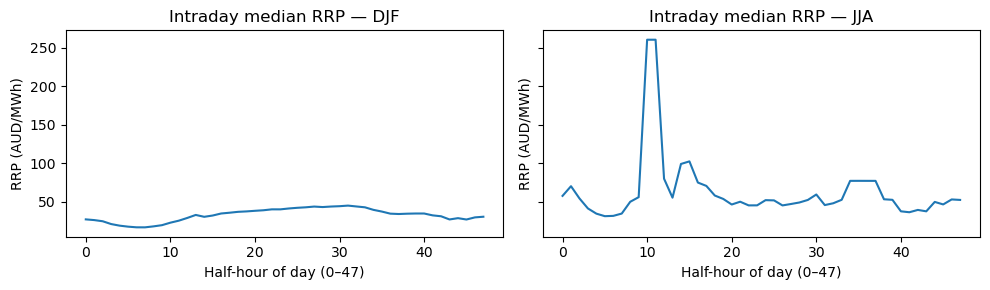

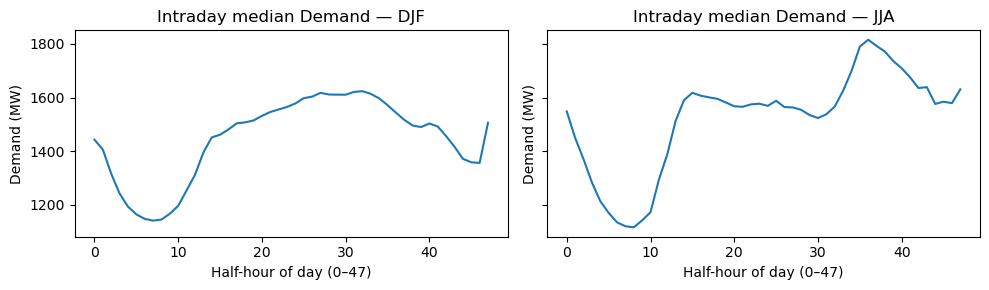

C:\Users\scm03\AppData\Local\Temp\ipykernel_53832\4160109396.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m = df.groupby(q)["rrp_w"].median()


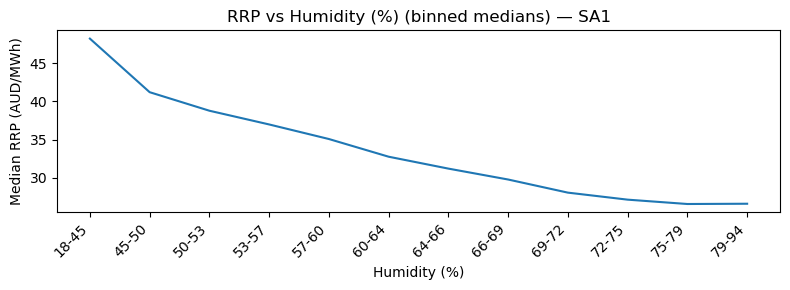

C:\Users\scm03\AppData\Local\Temp\ipykernel_53832\4160109396.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m = df.groupby(q)["rrp_w"].median()


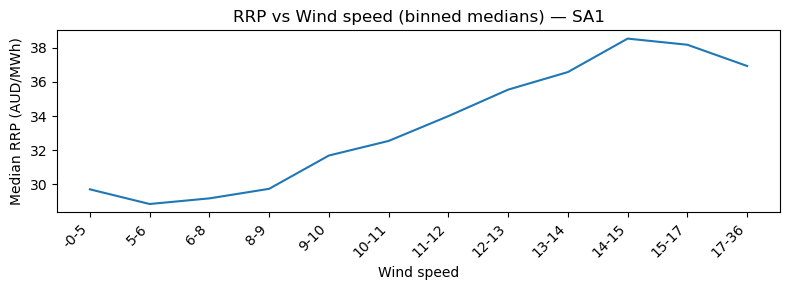

In [31]:
# === 3) Descriptive EDA ===
for col, ylabel, title in [("rrp_w","RRP (AUD/MWh)","Intraday median RRP"),
                           ("demand_mw","Demand (MW)","Intraday median Demand")]:
    if col in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(10,3), sharey=True)
        for ax, season in zip(axes, ["DJF","JJA"]):
            sub = df[df["season"]==season]
            prof = sub.groupby("tod")[col].median()
            if ROLLING_WINDOW and ROLLING_WINDOW>1:
                prof = prof.rolling(ROLLING_WINDOW, center=True, min_periods=1).median()
            ax.plot(prof.index, prof.values)
            if Y_MAX_PRICE and col.startswith("rrp"):
                ax.set_ylim(0, Y_MAX_PRICE)
            ax.set_title(f"{title} — {season}")
            ax.set_xlabel("Half-hour of day (0–47)")
            ax.set_ylabel(ylabel)
        fig.tight_layout()
        fig.savefig(os.path.join(OUTDIR, f"profile_{col}_DJF_JJA_{REGIONID}.png"), dpi=150, bbox_inches="tight")
        plt.show()

for var, label in [("rel_humidity","Humidity (%)"), ("wind_speed","Wind speed")]:
    if var in df.columns:
        q = pd.qcut(df[var], q=N_BINS, duplicates="drop")
        m = df.groupby(q)["rrp_w"].median()
        x = [f"{iv.left:.0f}-{iv.right:.0f}" for iv in m.index]
        plt.figure(figsize=(8,3))
        plt.plot(range(len(m)), m.values)
        if Y_MAX_PRICE:
            plt.ylim(0, Y_MAX_PRICE)
        plt.xticks(range(len(m)), x, rotation=45, ha="right")
        plt.xlabel(label); plt.ylabel("Median RRP (AUD/MWh)")
        plt.title(f"RRP vs {label} (binned medians) — {REGIONID}")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, f"binned_{var}_RRP_{REGIONID}.png"), dpi=150, bbox_inches="tight")
        plt.show()

In [33]:
# === 4) OLS + Huber regression, metrics (robust numeric casting) ===
from IPython.display import display

# Predictors we aim to use (only those present will be used)
features = ["temp_c_c","temp2","rel_humidity","wind_speed","demand_mw","tod_s","is_weekend"]
avail = [c for c in features if c in df.columns]

if not avail:
    raise ValueError(f"No predictor columns available in df. Expected any of: {features}")

# Drop rows with missing y/X/season
mod = df.dropna(subset=["rrp_w", "season"] + avail).copy()

# Season dummies (JJA is the reference when drop_first=True)
season_dummies = pd.get_dummies(mod["season"], drop_first=True, dtype=float)

# Design matrix with intercept
X = pd.concat(
    [
        pd.Series(1.0, index=mod.index, name="Intercept"),
        mod[avail],
        season_dummies,  # columns like "DJF" and/or "OTHER" (float)
    ],
    axis=1,
)

# Target
y = mod["rrp_w"]

# Ensure numeric float64 and remove any non-finite rows (so statsmodels doesn't choke)
X = X.apply(pd.to_numeric, errors="coerce").astype("float64")
y = pd.to_numeric(y, errors="coerce").astype("float64")

good = np.isfinite(X.to_numpy()).all(axis=1) & np.isfinite(y.to_numpy())
X = X.loc[good]
y = y.loc[good]

# Train/test split preserving time order
n = len(X)
if n < 50:
    print(f"Warning: small sample size after filtering (n={n}). Results may be unstable.")
split_idx = max(1, int(n * 0.8))
if split_idx >= n:
    split_idx = max(1, int(n * 0.75))

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx].to_numpy(), y.iloc[split_idx:].to_numpy()

# Fit OLS
if HAVE_SM:
    ols_fit = sm.OLS(y_train, X_train.to_numpy()).fit()
    ols_params = dict(zip(X_train.columns, ols_fit.params))
    yhat_train = ols_fit.predict(X_train.to_numpy())
    yhat_test  = ols_fit.predict(X_test.to_numpy())
else:
    beta, *_ = np.linalg.lstsq(X_train.to_numpy(), y_train, rcond=None)
    ols_params = dict(zip(X_train.columns, beta))
    yhat_train = X_train.to_numpy() @ beta
    yhat_test  = X_test.to_numpy() @ beta

# Fit Huber (robust to outliers) on standardized features
scaler = StandardScaler(with_mean=True, with_std=True)
Xh_train = scaler.fit_transform(X_train.to_numpy())
Xh_test  = scaler.transform(X_test.to_numpy())
huber = HuberRegressor().fit(Xh_train, y_train)
yhat_h_train = huber.predict(Xh_train)
yhat_h_test  = huber.predict(Xh_test)

def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

ols_train_m = reg_metrics(y_train, yhat_train)
ols_test_m  = reg_metrics(y_test,  yhat_test)
hub_train_m = reg_metrics(y_train, yhat_h_train)
hub_test_m  = reg_metrics(y_test,  yhat_h_test)

metrics_tbl = pd.DataFrame(
    [
        {"Model": "OLS (train)",   **ols_train_m},
        {"Model": "OLS (test)",    **ols_test_m},
        {"Model": "Huber (train)", **hub_train_m},
        {"Model": "Huber (test)",  **hub_test_m},
    ]
).round(3)

print(metrics_tbl)
metrics_tbl.to_csv(os.path.join(OUTDIR, f"metrics_{REGIONID}.csv"), index=False)

coef_tbl = pd.DataFrame({"feature": list(ols_params.keys()), "coef_ols": list(ols_params.values())})
coef_tbl.to_csv(os.path.join(OUTDIR, f"coefficients_OLS_{REGIONID}.csv"), index=False)
display(coef_tbl)

# Temperature turning point (only if quadratic term is present and non-zero)
if ("temp_c_c" in ols_params) and ("temp2" in ols_params) and (ols_params["temp2"] != 0) and ("temp_c" in df.columns):
    T_star_centered = -ols_params["temp_c_c"] / (2 * ols_params["temp2"])
    T_star = T_star_centered + df["temp_c"].median()
    print(f"Estimated turning point (Temp*): {T_star:.2f} °C (holding other variables constant)")


           Model     MAE    RMSE     R2
0    OLS (train)  13.483  23.396  0.404
1     OLS (test)  54.296  66.042 -1.003
2  Huber (train)  12.443  24.803  0.330
3   Huber (test)  56.555  69.058 -1.190


c:\Users\scm03\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\scm03\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\scm03\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\scm03\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the 

,feature,coef_ols
0,Intercept,-31.548727
1,temp_c_c,0.718949
2,temp2,0.351217
3,rel_humidity,0.028019
4,wind_speed,0.130631
5,demand_mw,0.039891
6,tod_s,-1.518604
7,is_weekend,0.449089
8,JJA,12.986480
9,OTHER,2.711651


Estimated turning point (Temp*): 19.04 °C (holding other variables constant)


In [37]:
# === 4A) Extended feature engineering: cyclic time-of-day, lags, seasonal interactions ===
import numpy as np
import pandas as pd

# Cyclic time-of-day encoding (48 half-hour slots)
if "tod" not in df.columns:
    t = df["timestamp"]
    df["tod"] = t.dt.hour*2 + (t.dt.minute//30)
df["tod_sin"] = np.sin(2*np.pi * df["tod"]/48.0)
df["tod_cos"] = np.cos(2*np.pi * df["tod"]/48.0)

# Simple lags (avoid lookahead/leakage by time-splitting later)
df = df.sort_values("timestamp").copy()
if "demand_mw" in df.columns:
    df["demand_lag1"] = df["demand_mw"].shift(1)
# Use winsorized RRP for stability in lag (you already computed rrp_w)
if "rrp_w" in df.columns:
    df["rrp_w_lag1"] = df["rrp_w"].shift(1)

# Season dummies (JJA reference as before)
season_dummies_full = pd.get_dummies(df["season"], drop_first=True)
# Create seasonal interactions for temperature (main nonlinearity) and wind/humidity
# Interactions only with DJF to compare against JJA baseline; you can add OTHER similarly.
if "temp_c_c" in df.columns:
    df["temp_c_c_x_DJF"] = df["temp_c_c"] * season_dummies_full.get("DJF", 0)
if "temp2" in df.columns:
    df["temp2_x_DJF"] = df["temp2"] * season_dummies_full.get("DJF", 0)
if "wind_speed" in df.columns:
    df["wind_speed_x_DJF"] = df["wind_speed"] * season_dummies_full.get("DJF", 0)
if "rel_humidity" in df.columns:
    df["rel_humidity_x_DJF"] = df["rel_humidity"] * season_dummies_full.get("DJF", 0)

print("Extended features ready.",
      "Columns added:",
      [c for c in ["tod_sin","tod_cos","demand_lag1","rrp_w_lag1",
                   "temp_c_c_x_DJF","temp2_x_DJF","wind_speed_x_DJF","rel_humidity_x_DJF"]
       if c in df.columns])


Extended features ready. Columns added: ['tod_sin', 'tod_cos', 'demand_lag1', 'rrp_w_lag1', 'temp_c_c_x_DJF', 'temp2_x_DJF', 'wind_speed_x_DJF', 'rel_humidity_x_DJF']


In [38]:
# === 4B) OLS with HC1 robust SEs (baseline model) ===
import numpy as np, pandas as pd, os

if not HAVE_SM:
    raise ImportError("statsmodels not available; install statsmodels to get robust SEs.")

# Rebuild baseline X so this cell is self-contained
features = ["temp_c_c","temp2","rel_humidity","wind_speed","demand_mw","tod_s","is_weekend"]
avail = [c for c in features if c in df.columns]
mod = df.dropna(subset=["rrp_w","season"] + avail).copy()

season_dummies = pd.get_dummies(mod["season"], drop_first=True, dtype=float)  # JJA reference
X = pd.concat([pd.Series(1.0, index=mod.index, name="Intercept"), mod[avail], season_dummies], axis=1)
y = pd.to_numeric(mod["rrp_w"], errors="coerce").astype("float64")

X = X.apply(pd.to_numeric, errors="coerce").astype("float64")
good = np.isfinite(X.to_numpy()).all(axis=1) & np.isfinite(y.to_numpy())
X, y = X.loc[good], y.loc[good]

# Time-ordered split
n = len(X); split_idx = max(1, int(n*0.8))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx].to_numpy(), y.iloc[split_idx:].to_numpy()

# OLS with HC1 robust covariance
ols_fit_hc1 = sm.OLS(y_train, X_train.to_numpy()).fit(cov_type="HC1")
params = pd.Series(ols_fit_hc1.params, index=X_train.columns, name="coef")
bse = pd.Series(ols_fit_hc1.bse, index=X_train.columns, name="robust_se")
pvals = pd.Series(ols_fit_hc1.pvalues, index=X_train.columns, name="p_value")

coef_hc1 = pd.concat([params, bse, pvals], axis=1)
coef_hc1.to_csv(os.path.join(OUTDIR, f"coefficients_OLS_HC1_{REGIONID}.csv"))
print(coef_hc1.round(4))

# Metrics
yhat_train = ols_fit_hc1.predict(X_train.to_numpy())
yhat_test  = ols_fit_hc1.predict(X_test.to_numpy())

def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    ss_res = np.sum((y_true - y_pred)**2); ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot>0 else np.nan
    return mae, rmse, r2

print("\nOLS+HC1 metrics (train/test):")
for name, yt, yp in [("train", y_train, yhat_train), ("test", y_test, yhat_test)]:
    mae, rmse, r2 = reg_metrics(yt, yp)
    print(f"{name}: MAE={mae:.3f} RMSE={rmse:.3f} R2={r2:.3f}")


                 coef  robust_se  p_value
Intercept    -31.5487     1.0694   0.0000
temp_c_c       0.7189     0.0321   0.0000
temp2          0.3512     0.0073   0.0000
rel_humidity   0.0280     0.0078   0.0003
wind_speed     0.1306     0.0188   0.0000
demand_mw      0.0399     0.0005   0.0000
tod_s         -1.5186     0.1985   0.0000
is_weekend     0.4491     0.1542   0.0036
JJA           12.9865     2.5261   0.0000
OTHER          2.7117     0.1319   0.0000

OLS+HC1 metrics (train/test):
train: MAE=13.483 RMSE=23.396 R2=0.404
test: MAE=54.296 RMSE=66.042 R2=-1.003


c:\Users\scm03\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\scm03\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [39]:
# === 4C) Extended OLS: add interactions (× DJF), cyclic TOD, lags; HC1 robust SEs ===
import numpy as np, pandas as pd, os

if not HAVE_SM:
    raise ImportError("statsmodels not available; install statsmodels to get robust SEs.")

ext_features = [
    "temp_c_c","temp2","rel_humidity","wind_speed","demand_mw",
    "tod_sin","tod_cos","is_weekend",
    "demand_lag1","rrp_w_lag1",
    "temp_c_c_x_DJF","temp2_x_DJF","wind_speed_x_DJF","rel_humidity_x_DJF",
]
avail_ext = [c for c in ext_features if c in df.columns]
mod = df.dropna(subset=["rrp_w","season"] + avail_ext).copy()

season_dummies = pd.get_dummies(mod["season"], drop_first=True, dtype=float)  # JJA reference
X = pd.concat([pd.Series(1.0, index=mod.index, name="Intercept"), mod[avail_ext], season_dummies], axis=1)
y = pd.to_numeric(mod["rrp_w"], errors="coerce").astype("float64")

X = X.apply(pd.to_numeric, errors="coerce").astype("float64")
good = np.isfinite(X.to_numpy()).all(axis=1) & np.isfinite(y.to_numpy())
X, y = X.loc[good], y.loc[good]

n = len(X); split_idx = max(1, int(n*0.8))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx].to_numpy(), y.iloc[split_idx:].to_numpy()

ols_ext = sm.OLS(y_train, X_train.to_numpy()).fit(cov_type="HC1")
params = pd.Series(ols_ext.params, index=X_train.columns, name="coef")
bse = pd.Series(ols_ext.bse, index=X_train.columns, name="robust_se")
pvals = pd.Series(ols_ext.pvalues, index=X_train.columns, name="p_value")
coef_ext = pd.concat([params, bse, pvals], axis=1)
coef_ext.to_csv(os.path.join(OUTDIR, f"coefficients_OLS_EXT_HC1_{REGIONID}.csv"))
print(coef_ext.round(4))

yhat_tr = ols_ext.predict(X_train.to_numpy())
yhat_te = ols_ext.predict(X_test.to_numpy())

def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    ss_res = np.sum((y_true - y_pred)**2); ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot>0 else np.nan
    return mae, rmse, r2

print("\nExtended OLS+HC1 metrics (train/test):")
for name, yt, yp in [("train", y_train, yhat_tr), ("test", y_test, yhat_te)]:
    mae, rmse, r2 = reg_metrics(yt, yp)
    print(f"{name}: MAE={mae:.3f} RMSE={rmse:.3f} R2={r2:.3f}")


                      coef  robust_se  p_value
Intercept          -4.3904     0.6230   0.0000
temp_c_c            0.1985     0.0198   0.0000
temp2               0.0712     0.0047   0.0000
rel_humidity        0.0061     0.0048   0.2042
wind_speed         -0.0004     0.0123   0.9772
demand_mw           0.0409     0.0010   0.0000
tod_sin             0.6683     0.0730   0.0000
tod_cos            -0.5421     0.0780   0.0000
is_weekend         -0.1562     0.0927   0.0918
demand_lag1        -0.0342     0.0010   0.0000
rrp_w_lag1          0.8065     0.0073   0.0000
temp_c_c_x_DJF     -0.0000     0.0000   0.2156
temp2_x_DJF         0.0000     0.0000      NaN
wind_speed_x_DJF    0.0000     0.0000      NaN
rel_humidity_x_DJF  0.0000     0.0000      NaN
JJA                 2.8054     2.2220   0.2067
OTHER               0.5716     0.0800   0.0000

Extended OLS+HC1 metrics (train/test):
train: MAE=4.955 RMSE=13.799 R2=0.793
test: MAE=14.858 RMSE=23.587 R2=0.745


c:\Users\scm03\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\scm03\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [40]:
# === 4D) Regularization: Ridge/Lasso with time-series CV (standardized X) ===
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import TimeSeriesSplit
import numpy as np, pandas as pd, os

# Use the same extended design as in 4C for a fair comparison
ext_features = [
    "temp_c_c","temp2","rel_humidity","wind_speed","demand_mw",
    "tod_sin","tod_cos","is_weekend",
    "demand_lag1","rrp_w_lag1",
    "temp_c_c_x_DJF","temp2_x_DJF","wind_speed_x_DJF","rel_humidity_x_DJF",
]
avail_ext = [c for c in ext_features if c in df.columns]
mod = df.dropna(subset=["rrp_w","season"] + avail_ext).copy()
season_dummies = pd.get_dummies(mod["season"], drop_first=True, dtype=float)

X = pd.concat([mod[avail_ext], season_dummies], axis=1).apply(pd.to_numeric, errors="coerce").astype("float64")
y = pd.to_numeric(mod["rrp_w"], errors="coerce").astype("float64")
good = np.isfinite(X.to_numpy()).all(axis=1) & np.isfinite(y.to_numpy())
X, y = X.loc[good], y.loc[good]

n = len(X); split_idx = max(1, int(n*0.8))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

tscv = TimeSeriesSplit(n_splits=5)
alphas = np.logspace(-3, 3, 13)

ridge = make_pipeline(StandardScaler(with_mean=True, with_std=True),
                      RidgeCV(alphas=alphas, cv=tscv))
ridge.fit(X_train, y_train)
yhat_r_tr = ridge.predict(X_train)
yhat_r_te = ridge.predict(X_test)

lasso = make_pipeline(StandardScaler(with_mean=True, with_std=True),
                      LassoCV(alphas=alphas, cv=tscv, n_jobs=None, max_iter=20000))
lasso.fit(X_train, y_train)
yhat_l_tr = lasso.predict(X_train)
yhat_l_te = lasso.predict(X_test)

def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    ss_res = np.sum((y_true - y_pred)**2); ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot>0 else np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

metrics_reg = pd.DataFrame([
    {"Model":"Ridge (train)", **reg_metrics(y_train, yhat_r_tr)},
    {"Model":"Ridge (test)",  **reg_metrics(y_test,  yhat_r_te)},
    {"Model":"Lasso (train)", **reg_metrics(y_train, yhat_l_tr)},
    {"Model":"Lasso (test)",  **reg_metrics(y_test,  yhat_l_te)},
]).round(3)
print(metrics_reg)
metrics_reg.to_csv(os.path.join(OUTDIR, f"metrics_regularization_{REGIONID}.csv"), index=False)

# Extract standardized coefficients for interpretability snapshot
ridge_coefs = ridge.named_steps["ridgecv"].coef_
lasso_coefs = lasso.named_steps["lassocv"].coef_
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef_ridge_std": ridge_coefs,
    "coef_lasso_std": lasso_coefs,
})
coef_df.to_csv(os.path.join(OUTDIR, f"coefficients_regularization_std_{REGIONID}.csv"), index=False)
print(coef_df.head(12))


           Model     MAE    RMSE     R2
0  Ridge (train)   4.954  13.799  0.793
1   Ridge (test)  14.897  23.631  0.744
2  Lasso (train)   4.942  13.806  0.792
3   Lasso (test)  14.965  23.724  0.742
           feature  coef_ridge_std  coef_lasso_std
0         temp_c_c        0.739762        0.525213
1            temp2        1.493348        1.455182
2     rel_humidity        0.083289        0.000000
3       wind_speed       -0.002683       -0.000000
4        demand_mw       12.722810       10.590425
5          tod_sin        0.495028        0.529005
6          tod_cos       -0.435573       -0.526250
7       is_weekend       -0.070230       -0.011425
8      demand_lag1      -10.505744       -8.257768
9       rrp_w_lag1       24.411536       24.408663
10  temp_c_c_x_DJF        0.000000        0.000000
11     temp2_x_DJF        0.000000        0.000000


c:\Users\scm03\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\scm03\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\scm03\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\scm03\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the 

In [42]:
# === 4E) Diagnostics: Breusch–Pagan (heteroskedasticity), Durbin–Watson (autocorrelation) ===
if HAVE_SM:
    from statsmodels.stats.diagnostic import het_breuschpagan
    from statsmodels.stats.stattools import durbin_watson

    # Reuse the baseline OLS+HC1 design from 4B for diagnostics
    features = ["temp_c_c","temp2","rel_humidity","wind_speed","demand_mw","tod_s","is_weekend"]
    avail = [c for c in features if c in df.columns]
    mod = df.dropna(subset=["rrp_w","season"] + avail).copy()
    season_dummies = pd.get_dummies(mod["season"], drop_first=True, dtype=float)
    X = pd.concat([pd.Series(1.0, index=mod.index, name="Intercept"), mod[avail], season_dummies], axis=1)
    y = pd.to_numeric(mod["rrp_w"], errors="coerce").astype("float64")

    X = X.apply(pd.to_numeric, errors="coerce").astype("float64")
    good = np.isfinite(X.to_numpy()).all(axis=1) & np.isfinite(y.to_numpy())
    X, y = X.loc[good], y.loc[good]

    n = len(X); split_idx = max(1, int(n*0.8))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx].to_numpy(), y.iloc[split_idx:].to_numpy()

    ols_base = sm.OLS(y_train, X_train.to_numpy()).fit()
    resid = y_train - ols_base.predict(X_train.to_numpy())

    # Breusch–Pagan: using exogs without the intercept column
    exogs = X_train.to_numpy()  # include the Intercept column
    lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(resid, exogs)
    print(f"Breusch–Pagan: LM={lm:.2f}, p={lm_pvalue:.4f};  F={fvalue:.2f}, p={f_pvalue:.4f}")

    # Durbin–Watson on residuals (0=positive autocorr, 2≈none, 4=negative autocorr)
    dw = durbin_watson(resid)
    print(f"Durbin–Watson: {dw:.3f}")
else:
    print("statsmodels not available; skipping BP/DW diagnostics.")


Breusch–Pagan: LM=15436.19, p=0.0000;  F=1940.82, p=0.0000
Durbin–Watson: 0.386


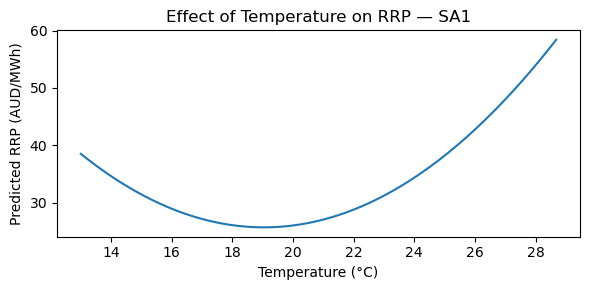

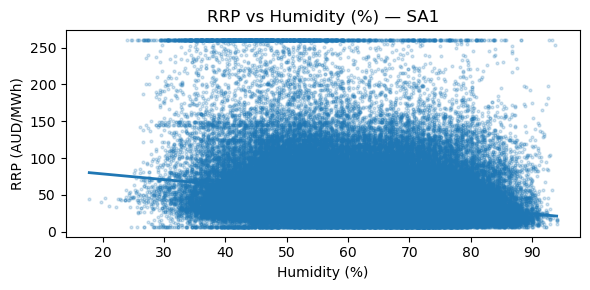

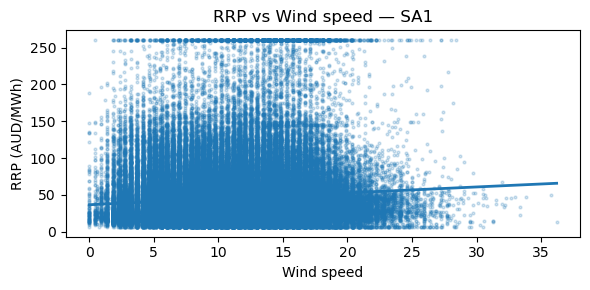

In [34]:
# === 5) Effect plots ===
base = {c: X[c].median() if c in X.columns else 0.0 for c in X.columns}
base["Intercept"] = 1.0
for sname in ["DJF","OTHER"]:
    if sname in X.columns: base[sname] = 0.0

if "temp_c_c" in X.columns and "temp2" in X.columns:
    grid_T = np.linspace(df["temp_c"].quantile(0.02), df["temp_c"].quantile(0.98), 200)
    Xp = []
    medT = df["temp_c"].median()
    for T in grid_T:
        b = base.copy()
        Tc = T - medT
        b["temp_c_c"] = Tc; b["temp2"] = Tc**2
        Xp.append([b.get(c, 0.0) for c in X.columns])
    Xp = np.asarray(Xp)
    if HAVE_SM:
        yhat = ols_fit.predict(Xp)
    else:
        beta_vec = coef_tbl.set_index("feature").reindex(X.columns)["coef_ols"].to_numpy()
        yhat = Xp @ beta_vec

    plt.figure(figsize=(6,3))
    plt.plot(grid_T, yhat)
    if Y_MAX_PRICE:
        plt.ylim(0, Y_MAX_PRICE)
    plt.xlabel("Temperature (°C)"); plt.ylabel("Predicted RRP (AUD/MWh)")
    plt.title(f"Effect of Temperature on RRP — {REGIONID}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"effect_T_{REGIONID}.png"), dpi=150, bbox_inches="tight")
    plt.show()

for var, label in [("rel_humidity","Humidity (%)"), ("wind_speed","Wind speed")]:
    if var in X.columns:
        xs = df[var]
        plt.figure(figsize=(6,3))
        plt.scatter(xs, df["rrp_w"], s=4, alpha=0.2)
        coef = np.polyfit(xs.dropna(), df.loc[xs.dropna().index, "rrp_w"], 1)
        xr = np.linspace(xs.min(), xs.max(), 200)
        yr = coef[0]*xr + coef[1]
        plt.plot(xr, yr, linewidth=2)
        if Y_MAX_PRICE:
            plt.ylim(0, Y_MAX_PRICE)
        plt.xlabel(label); plt.ylabel("RRP (AUD/MWh)")
        plt.title(f"RRP vs {label} — {REGIONID}")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, f"scatter_line_{var}_{REGIONID}.png"), dpi=150, bbox_inches="tight")
        plt.show()

C:\Users\scm03\AppData\Local\Temp\ipykernel_53832\318879493.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curve = y.groupby(bins).median().to_numpy()


ValueError: x and y must have same first dimension, but have shapes (164179,) and (20,)

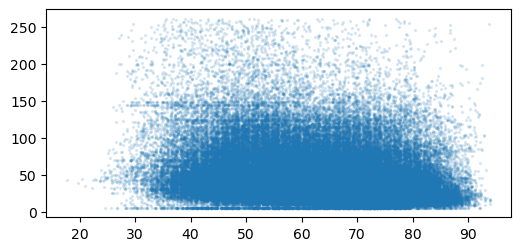

In [43]:
# RRP vs Humidity — hide winsor-capped points
g = df.dropna(subset=["rrp_w","rel_humidity"]).copy()

# Find the winsor cap; prefer raw rrp quantile if available
if "rrp" in g.columns:
    cap = g["rrp"].quantile(1 - WINSOR_P)
    mask = g["rrp"] < cap           # keep only uncapped raw prices
else:
    cap = g["rrp_w"].max()
    mask = g["rrp_w"] < cap         # fallback: drop the capped level

x = g.loc[mask, "rel_humidity"].astype(float)
y = g.loc[mask, "rrp_w"].astype(float)

plt.figure(figsize=(6,2.7))
plt.scatter(x, y, s=2, alpha=0.12)

# binned-median trend (on the kept points)
bins = pd.qcut(x, q=20, duplicates="drop")
mid  = bins.apply(lambda r: 0.5*(r.left + r.right)).to_numpy()
curve = y.groupby(bins).median().to_numpy()
plt.plot(mid, curve)

plt.xlabel("Humidity (%)")
plt.ylabel("RRP (AUD/MWh)")
plt.title(f"RRP vs Humidity (%) — {REGIONID}")
plt.tight_layout()
# plt.savefig(os.path.join(OUTDIR, f"rrp_vs_humidity_clean_{REGIONID}.png"), dpi=200)
plt.show()


C:\Users\scm03\AppData\Local\Temp\ipykernel_53832\2125030953.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curve = y.groupby(bins).median().to_numpy()


ValueError: x and y must have same first dimension, but have shapes (164179,) and (20,)

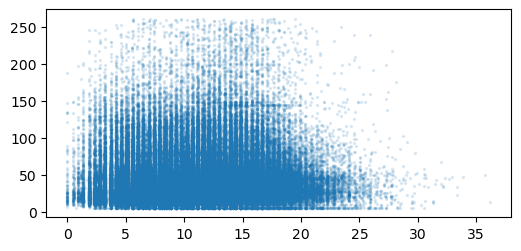

In [44]:
# RRP vs Wind — hide winsor-capped points
g = df.dropna(subset=["rrp_w","wind_speed"]).copy()

if "rrp" in g.columns:
    cap = g["rrp"].quantile(1 - WINSOR_P)
    mask = g["rrp"] < cap
else:
    cap = g["rrp_w"].max()
    mask = g["rrp_w"] < cap

x = g.loc[mask, "wind_speed"].astype(float)
y = g.loc[mask, "rrp_w"].astype(float)

plt.figure(figsize=(6,2.7))
plt.scatter(x, y, s=2, alpha=0.12)

bins = pd.qcut(x, q=20, duplicates="drop")
mid  = bins.apply(lambda r: 0.5*(r.left + r.right)).to_numpy()
curve = y.groupby(bins).median().to_numpy()
plt.plot(mid, curve)

plt.xlabel("Wind speed (km/h)")
plt.ylabel("RRP (AUD/MWh)")
plt.title(f"RRP vs Wind speed — {REGIONID}")
plt.tight_layout()
# plt.savefig(os.path.join(OUTDIR, f"rrp_vs_wind_clean_{REGIONID}.png"), dpi=200)
plt.show()


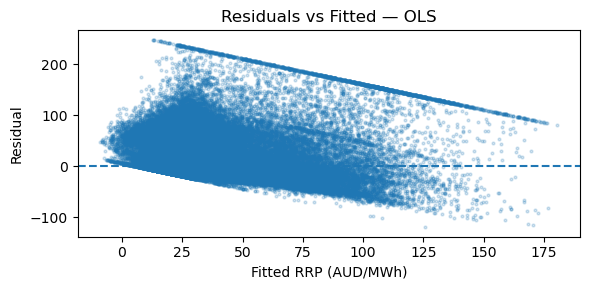

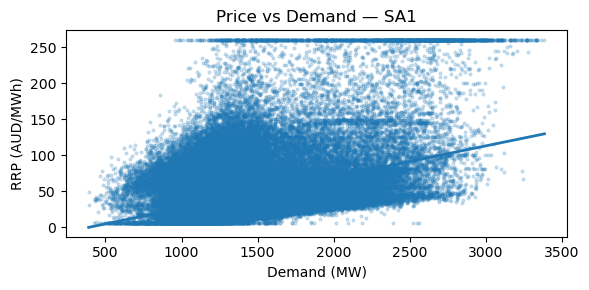

In [35]:
# === 6) Diagnostics ===
if HAVE_SM:
    fitted_all = ols_fit.predict(X.to_numpy())
    resid_all = y - fitted_all
else:
    beta_full, *_ = np.linalg.lstsq(X.to_numpy(), y, rcond=None)
    fitted_all = X.to_numpy() @ beta_full
    resid_all = y - fitted_all

plt.figure(figsize=(6,3))
plt.scatter(fitted_all, resid_all, s=4, alpha=0.2)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted RRP (AUD/MWh)")
plt.ylabel("Residual")
plt.title("Residuals vs Fitted — OLS")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, f"resid_vs_fitted_{REGIONID}.png"), dpi=150, bbox_inches="tight")
plt.show()

if "demand_mw" in df.columns:
    plt.figure(figsize=(6,3))
    plt.scatter(df["demand_mw"], df["rrp_w"], s=4, alpha=0.2)
    c = np.polyfit(df["demand_mw"], df["rrp_w"], 1)
    xr = np.linspace(float(df["demand_mw"].min()), float(df["demand_mw"].max()), 200)
    yr = c[0]*xr + c[1]
    plt.plot(xr, yr, linewidth=2)
    if Y_MAX_PRICE:
        plt.ylim(0, Y_MAX_PRICE)
    plt.xlabel("Demand (MW)"); plt.ylabel("RRP (AUD/MWh)")
    plt.title(f"Price vs Demand — {REGIONID}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"price_vs_demand_{REGIONID}.png"), dpi=150, bbox_inches="tight")
    plt.show()

In [36]:
# === 7) Optional: Spike classification (Logistic & kNN) ===
df["is_spike"] = (df["rrp_w"] >= df["rrp_w"].quantile(0.95)).astype(int)
cls_feats = [c for c in ["demand_mw","temp_c","rel_humidity","wind_speed","tod_s","is_weekend"] if c in df.columns]
clf_df = df.dropna(subset=cls_feats + ["is_spike"]).copy()

if len(clf_df) > 1000 and cls_feats:
    Xc = clf_df[cls_feats].to_numpy()
    yc = clf_df["is_spike"].to_numpy()
    Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=7, stratify=yc)

    from sklearn.preprocessing import StandardScaler
    scaler_c = StandardScaler()
    Xtr = scaler_c.fit_transform(Xc_train); Xte = scaler_c.transform(Xc_test)

    from sklearn.linear_model import LogisticRegression
    logit = LogisticRegression(max_iter=200).fit(Xtr, yc_train)
    ycp = logit.predict(Xte)
    print("\nLogistic spike classification:")
    print(classification_report(yc_test, ycp, digits=3))

    from sklearn.neighbors import KNeighborsClassifier
    knn = KNeighborsClassifier(n_neighbors=7).fit(Xtr, yc_train)
    ykp = knn.predict(Xte)
    print("\nkNN spike classification:")
    print(classification_report(yc_test, ykp, digits=3))
else:
    print("Skip classification: not enough rows or missing features.")


Logistic spike classification:
              precision    recall  f1-score   support

           0      0.953     0.999     0.975     31509
           1      0.732     0.061     0.112      1659

    accuracy                          0.952     33168
   macro avg      0.842     0.530     0.544     33168
weighted avg      0.942     0.952     0.932     33168


kNN spike classification:
              precision    recall  f1-score   support

           0      0.960     0.992     0.976     31509
           1      0.603     0.224     0.326      1659

    accuracy                          0.954     33168
   macro avg      0.782     0.608     0.651     33168
weighted avg      0.943     0.954     0.944     33168

